## Petrol Bunk Analysis Efficiency And Profitability

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_excel("C:/Users/HP/Documents/fuel_station_data_500_rows.xlsx")
print("This is DataSet :\n ",pd.DataFrame(df))


This is DataSet :
      Transaction_ID       Date   Time Fuel_Type  Quantity_Liters  \
0         TXN-1000 2023-08-21  14:02       CNG            12.01   
1         TXN-1001 2023-06-15   9:46       CNG            77.42   
2         TXN-1002 2023-06-04  12:27       CNG            42.52   
3         TXN-1003 2023-07-06  13:30       CNG            13.96   
4         TXN-1004 2023-07-02  23:15    Diesel            36.32   
..             ...        ...    ...       ...              ...   
495       TXN-1495 2023-07-06  21:23    Diesel            18.05   
496       TXN-1496 2023-07-15  20:17    Petrol            20.96   
497       TXN-1497 2023-08-22  21:24       CNG             8.07   
498       TXN-1498 2023-08-05  13:49    Petrol            35.57   
499       TXN-1499 2023-07-22  18:08    Petrol            19.45   

     Price_Per_Liter  Total_Amount  Profit               Shift Employee  ...  \
0              87.27       1048.08   83.85   Morning (6AM-2PM)   Vikram  ...   
1              

In [12]:
print("The First Five Rows of DataSet : \n",df.head())

The First Five Rows of DataSet : 
   Transaction_ID       Date   Time Fuel_Type  Quantity_Liters  \
0       TXN-1000 2023-08-21  14:02       CNG            12.01   
1       TXN-1001 2023-06-15   9:46       CNG            77.42   
2       TXN-1002 2023-06-04  12:27       CNG            42.52   
3       TXN-1003 2023-07-06  13:30       CNG            13.96   
4       TXN-1004 2023-07-02  23:15    Diesel            36.32   

   Price_Per_Liter  Total_Amount  Profit               Shift Employee  ...  \
0            87.27       1048.08   83.85   Morning (6AM-2PM)   Vikram  ...   
1            81.18       6285.32  502.83  Evening (2PM-10PM)   Vikram  ...   
2            80.87       3438.59  275.09    Night (10PM-6AM)   Vikram  ...   
3            78.70       1098.65   87.89    Night (10PM-6AM)      Raj  ...   
4           101.71       3694.11  443.29   Morning (6AM-2PM)     Neha  ...   

  Discount_Applied Loyalty_Points_Earned Transaction_Duration_Seconds  \
0             0.58              

In [13]:
print("The Summary of Dataset : \n",df.describe())

The Summary of Dataset : 
                       Date  Quantity_Liters  Price_Per_Liter  Total_Amount  \
count                  500       500.000000       500.000000    500.000000   
mean   2023-07-14 23:31:12        28.360820        98.912480   2800.750660   
min    2023-06-01 00:00:00         5.170000        76.100000    425.230000   
25%    2023-06-21 00:00:00        16.135000        90.712500   1540.032500   
50%    2023-07-13 00:00:00        27.860000       100.345000   2699.460000   
75%    2023-08-09 00:00:00        39.707500       107.420000   3829.017500   
max    2023-08-31 00:00:00        86.540000       120.870000   9569.470000   
std                    NaN        14.243549        11.519865   1442.934266   

            Profit  Discount_Applied  Loyalty_Points_Earned  \
count   500.000000        500.000000             500.000000   
mean    358.773980          0.629420               5.418000   
min      34.020000          0.000000               1.000000   
25%     181.735000

In [14]:
print("The Missing on DataSet : \n",df.isnull().sum())

The Missing on DataSet : 
 Transaction_ID                  0
Date                            0
Time                            0
Fuel_Type                       0
Quantity_Liters                 0
Price_Per_Liter                 0
Total_Amount                    0
Profit                          0
Shift                           0
Employee                        0
Payment_Method                  0
Customer_Type                   0
Nozzle_ID                       0
Tank_ID                         0
Vehicle_Type                    0
Discount_Applied                0
Loyalty_Points_Earned           0
Transaction_Duration_Seconds    0
Fuel_Temperature_Celsius        0
Ambient_Temperature_Celsius     0
Efficiency_Score                0
Customer_Satisfaction           0
Stock_Before                    0
Stock_After                     0
Hour                            0
dtype: int64


In [15]:
print("The information of Dataset : \n",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Transaction_ID                500 non-null    object        
 1   Date                          500 non-null    datetime64[ns]
 2   Time                          500 non-null    object        
 3   Fuel_Type                     500 non-null    object        
 4   Quantity_Liters               500 non-null    float64       
 5   Price_Per_Liter               500 non-null    float64       
 6   Total_Amount                  500 non-null    float64       
 7   Profit                        500 non-null    float64       
 8   Shift                         500 non-null    object        
 9   Employee                      500 non-null    object        
 10  Payment_Method                500 non-null    object        
 11  Customer_Type                 50

### Data visualization

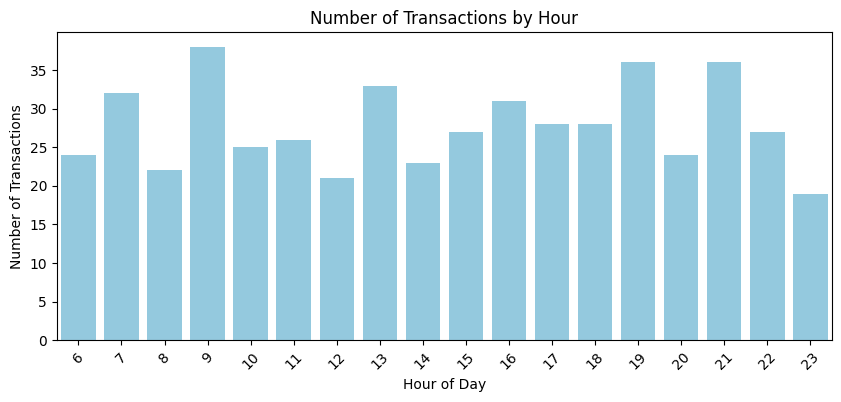

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Countplot: Transactions by Hour
df['Hour of Day'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Hour of Day', color='skyblue')
plt.title('Number of Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

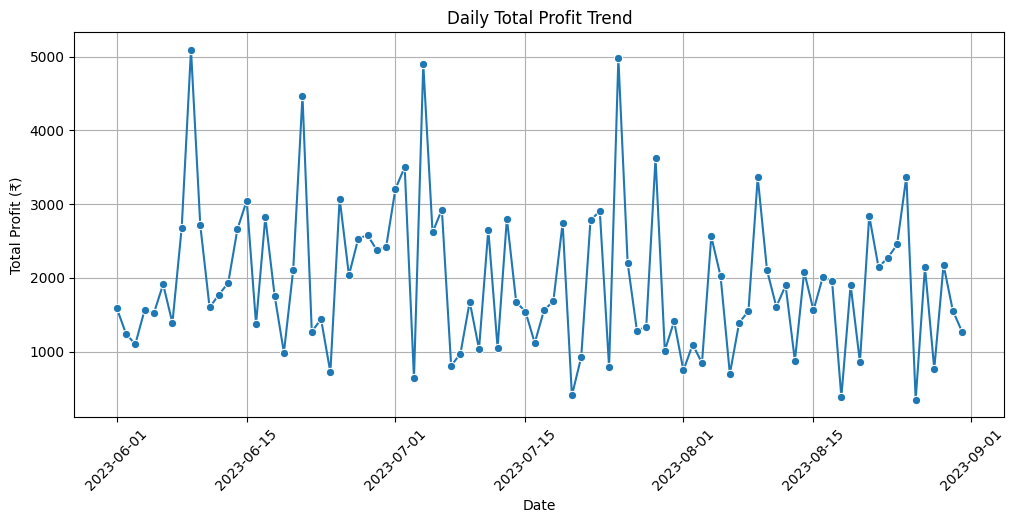

In [18]:
# 2. Line Plot: Daily Total Profit Trend
daily_profit = df.groupby('Date')['Profit'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_profit, x='Date', y='Profit', marker='o')
plt.title('Daily Total Profit Trend')
plt.xlabel('Date')
plt.ylabel('Total Profit (₹)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

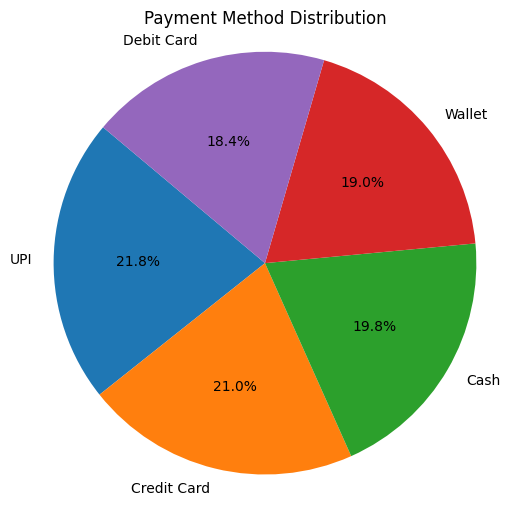

In [19]:
# 3. Pie Chart: Payment Method Distribution
plt.figure(figsize=(6, 6))
payment_counts = df['Payment_Method'].value_counts()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Payment Method Distribution')
plt.axis('equal')
plt.show()

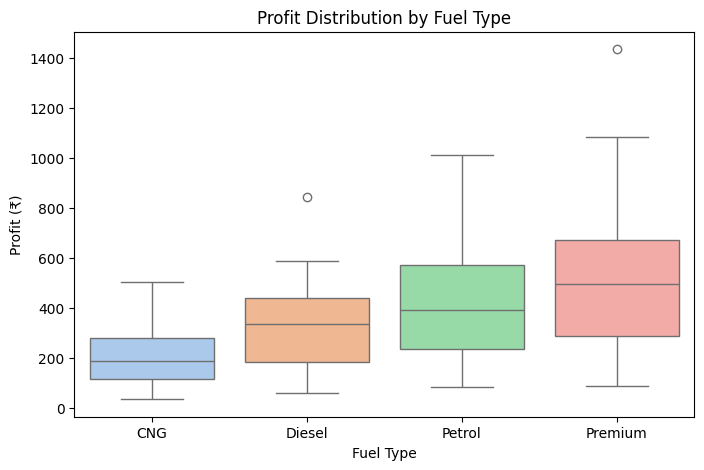

In [22]:
# 4. Boxplot: Profit Distribution by Fuel Type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Profit', palette='pastel',hue='Fuel_Type',legend=False)
plt.title('Profit Distribution by Fuel Type')
plt.ylabel('Profit (₹)')
plt.xlabel('Fuel Type')
plt.show()

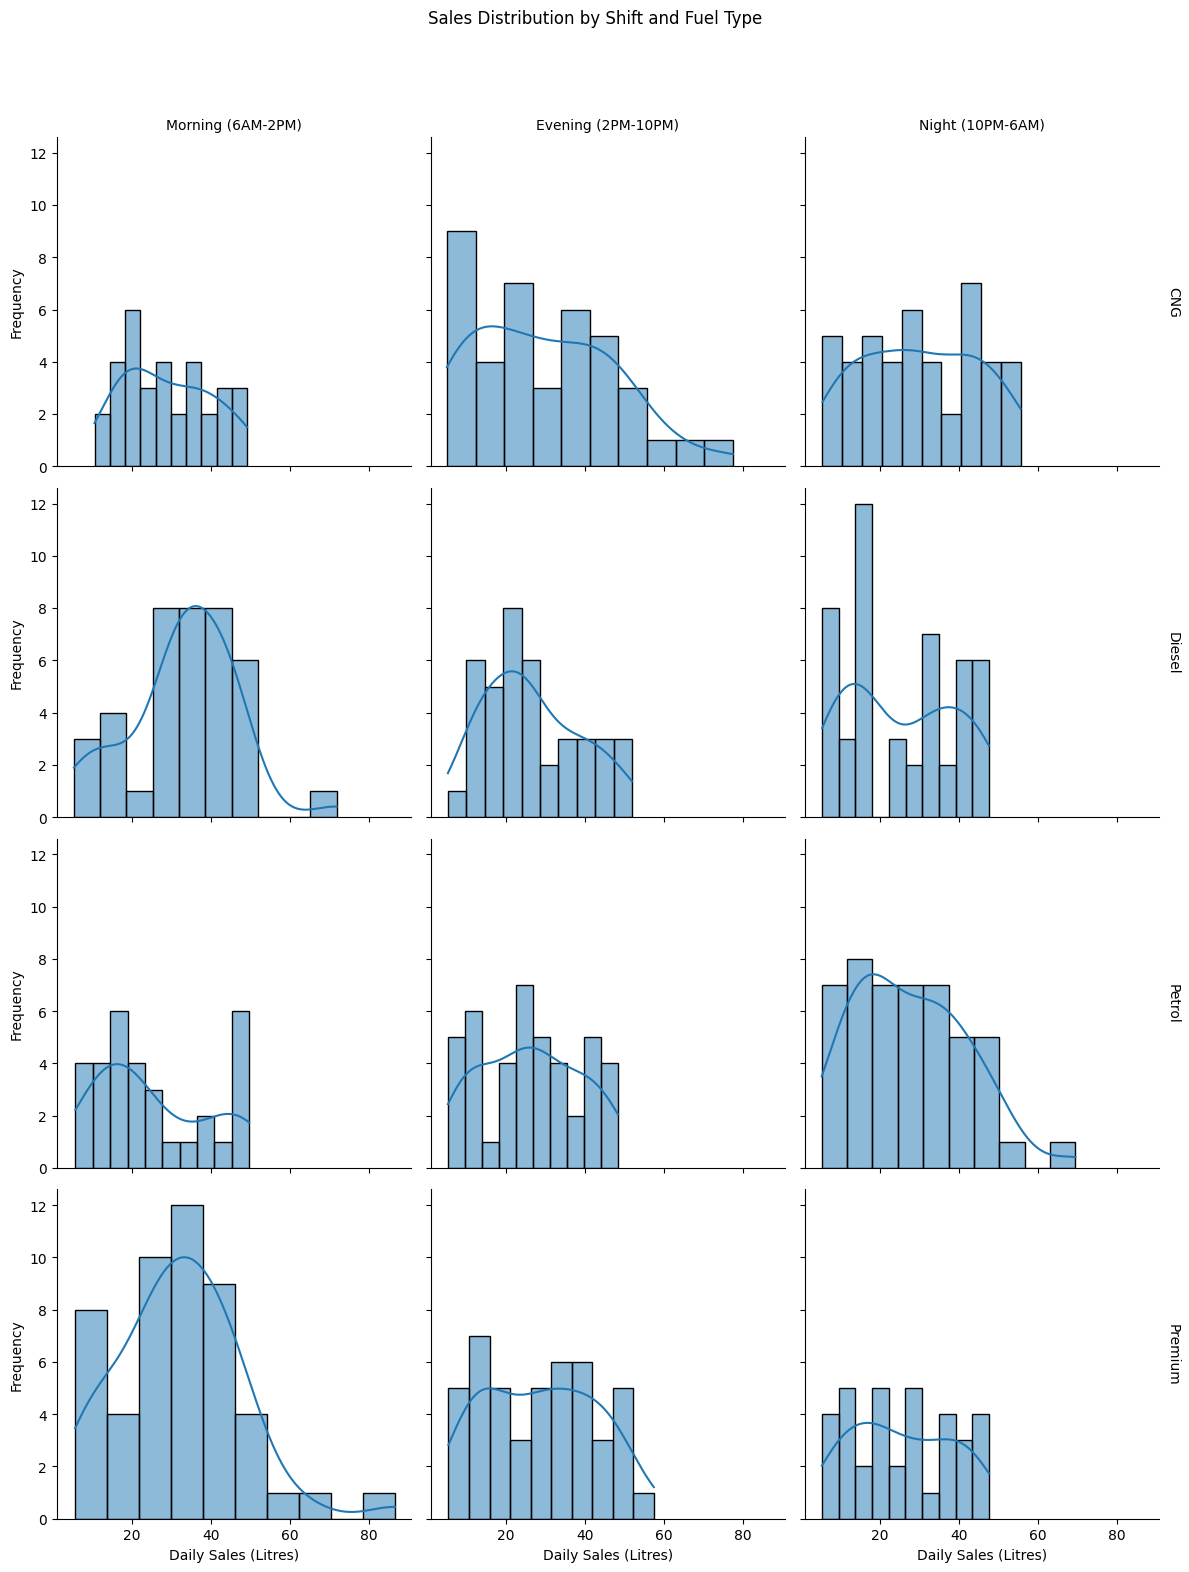

In [27]:
# 5. FacetGrid: Sales Distribution by Shift and Fuel Type
g = sns.FacetGrid(df, col='Shift', row='Fuel_Type', margin_titles=True, height=4)
g.map(sns.histplot, 'Quantity_Liters', bins=10, kde=True)
g.set_axis_labels('Daily Sales (Litres)', 'Frequency')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Sales Distribution by Shift and Fuel Type')
plt.show()